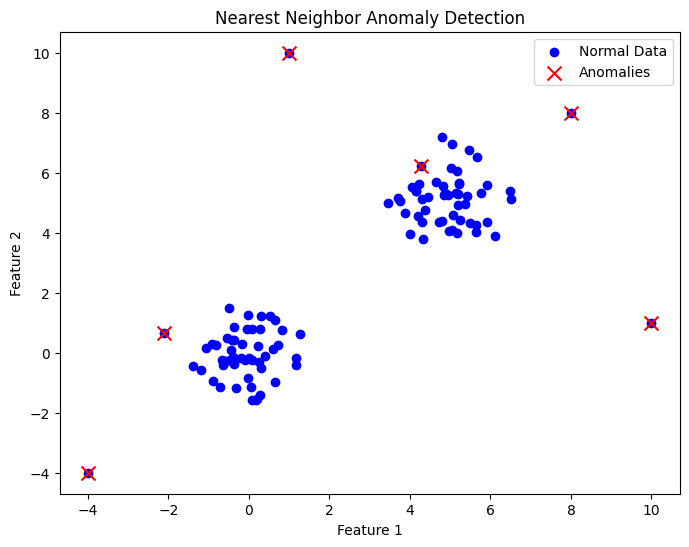

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.datasets import make_blobs

# Generate sample data with two clusters
X, _ = make_blobs(n_samples=100, centers=[[0, 0], [5, 5]], cluster_std=0.8, random_state=42)

# Adding some anomalies
X = np.vstack([X, [[8, 8], [-4, -4], [10, 1], [1, 10]]])

# Step 1: Fit Nearest Neighbors model
k = 3  # Number of neighbors
nbrs = NearestNeighbors(n_neighbors=k)
nbrs.fit(X)

# Step 2: Calculate anomaly scores (average distance to k nearest neighbors)
distances, _ = nbrs.kneighbors(X)
anomaly_scores = distances.mean(axis=1)

# Step 3: Define a threshold for anomaly detection
threshold = np.percentile(anomaly_scores, 95)  # Top 5% as anomalies
anomalies = anomaly_scores > threshold

# Step 4: Plot results
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c='blue', label="Normal Data")
plt.scatter(X[anomalies, 0], X[anomalies, 1], c='red', label="Anomalies", marker="x", s=100)
plt.title('Nearest Neighbor Anomaly Detection')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()
